In [65]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

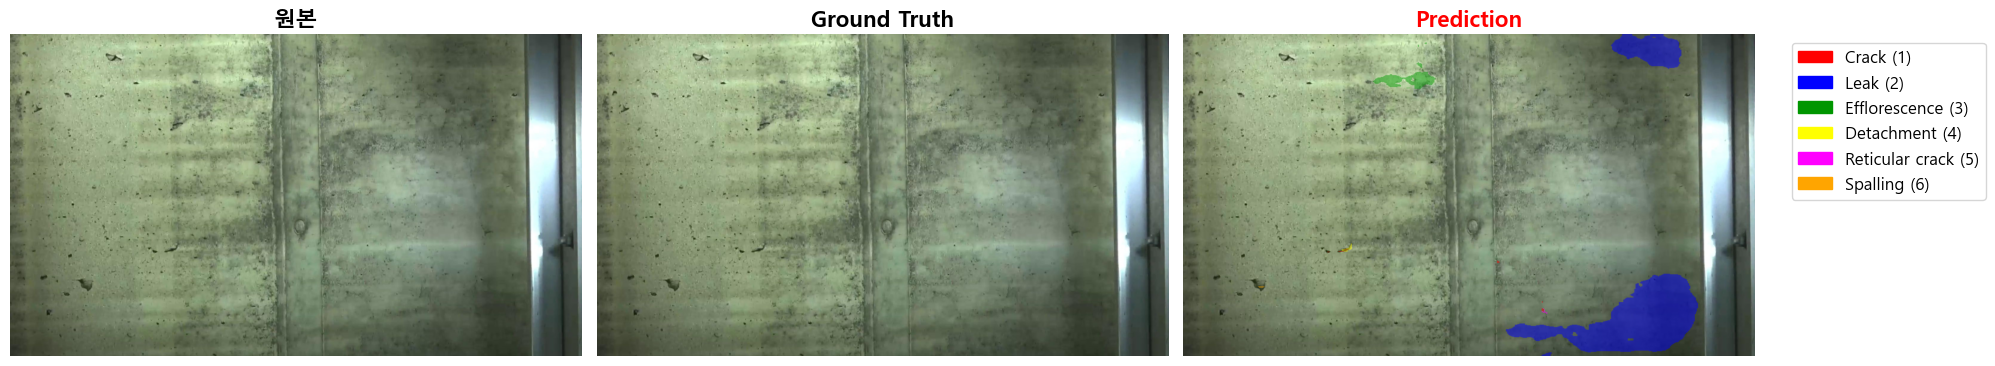

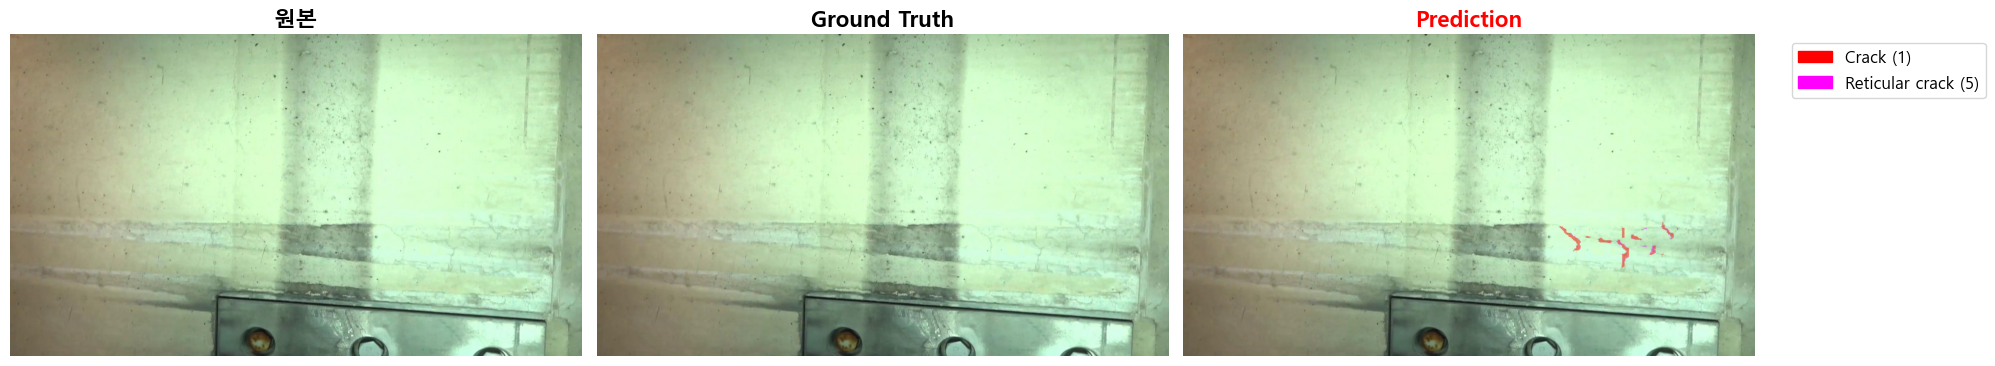

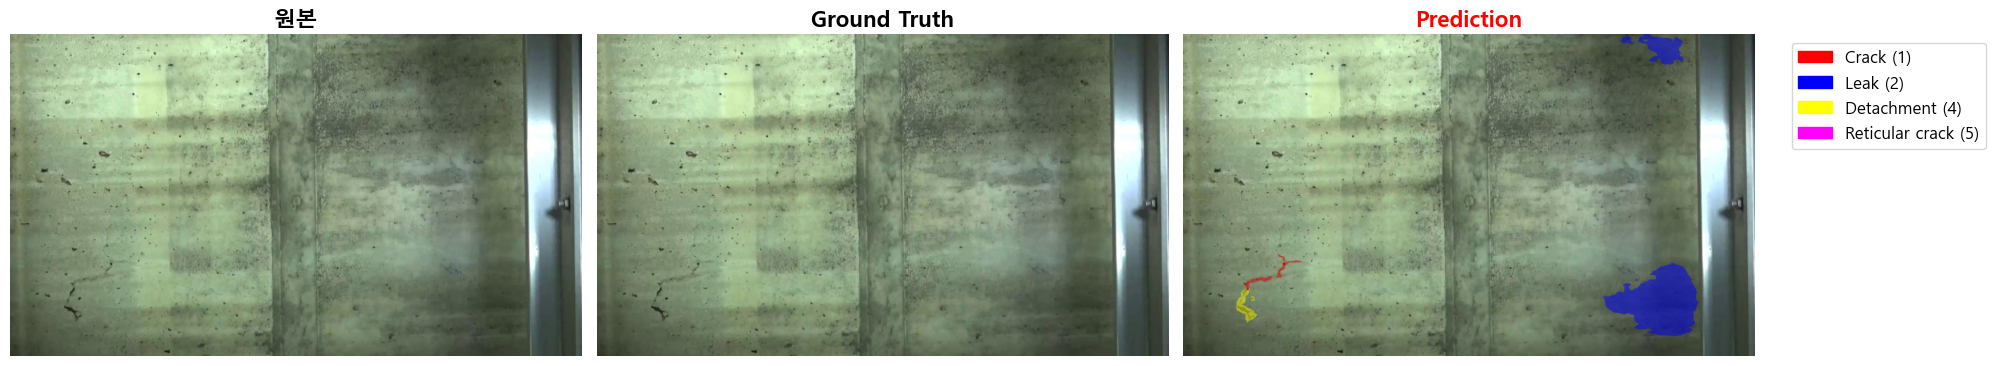

In [9]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False


VAL_IMAGE_DIR = r"D:\Study\HumanStudy\Dataset\Validation\01.원천데이터"
VAL_MASK_DIR = r"D:\Study\HumanStudy\Dataset\Validation_Masks_2"         
PRED_SAVE_DIR = r"D:\Study\HumanStudy\Dataset\Validation_Predictions_2"  

COLOR_MAP = {
    0: [0, 0, 0], 1: [255, 0, 0], 2: [0, 0, 255], 3: [0, 150, 0],
    4: [255, 255, 0], 5: [255, 0, 255], 6: [255, 165, 0], 7: [0, 255, 255],
    8: [139, 69, 19], 9: [128, 0, 128], 10: [0, 255, 0]
}
CLASS_NAMES = {
    0: "Background", 1: "Crack", 2: "Leak", 3: "Efflorescence",
    4: "Detachment", 5: "Reticular crack", 6: "Spalling",
    7: "Material separation", 8: "Rebar", 9: "Damage", 10: "Exhilaration"
}

def imread_korean(path, flags=cv2.IMREAD_COLOR):
    img_array = np.fromfile(path, np.uint8)
    return cv2.imdecode(img_array, flags)

def colorize_mask(mask_array):
    colored = np.zeros((*mask_array.shape, 3), dtype=np.uint8)
    for class_id in np.unique(mask_array):
        if class_id in COLOR_MAP:
            colored[mask_array == class_id] = COLOR_MAP[class_id]
    return colored

pred_paths = list(Path(PRED_SAVE_DIR).rglob("*.png"))
samples = random.sample(pred_paths, min(3, len(pred_paths)))

for pred_path in samples:
    mask_name = pred_path.name
    img_name = mask_name.replace('.png', '.jpg')
    
    img_search = list(Path(VAL_IMAGE_DIR).rglob(img_name))
    if not img_search: 
        continue
    
    img = imread_korean(str(img_search[0]), cv2.IMREAD_COLOR)
    if img is None: continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    orig_h, orig_w = img.shape[:2]
    
    gt_mask_path = os.path.join(VAL_MASK_DIR, mask_name)
    gt_mask = imread_korean(gt_mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = cv2.resize(gt_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    
    pred_mask = imread_korean(str(pred_path), cv2.IMREAD_GRAYSCALE)
    pred_mask = cv2.resize(pred_mask, (orig_w, orig_h), interpolation=cv2.INTER_NEAREST)
    
    
    gt_colored = colorize_mask(gt_mask)
    pred_colored = colorize_mask(pred_mask)
    
    gt_overlay = img.copy()
    gt_bool = gt_mask > 0
    gt_overlay[gt_bool] = (img[gt_bool] * 0.5 + gt_colored[gt_bool] * 0.5).astype(np.uint8)
    
    pred_overlay = img.copy()
    pred_bool = pred_mask > 0
    pred_overlay[pred_bool] = (img[pred_bool] * 0.5 + pred_colored[pred_bool] * 0.5).astype(np.uint8)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    axes[0].imshow(img)
    axes[0].set_title("원본", fontsize=16, fontweight='bold')
    axes[0].axis("off")
    
    axes[1].imshow(gt_overlay)
    axes[1].set_title("Ground Truth", fontsize=16, fontweight='bold')
    axes[1].axis("off")
    
    axes[2].imshow(pred_overlay)
    axes[2].set_title("Prediction", fontsize=16, fontweight='bold', color='red')
    axes[2].axis("off")
    
    present_classes = np.unique(np.concatenate((gt_mask, pred_mask)))
    legend_patches = [
        mpatches.Patch(color=np.array(COLOR_MAP[c])/255, label=f"{CLASS_NAMES[c]} ({c})") 
        for c in present_classes if c != 0
    ]
    if legend_patches:
        axes[2].legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12)
        
    plt.tight_layout()
    plt.show()



In [3]:
visualize_results(num_samples=5)

NameError: name 'visualize_results' is not defined